In [1]:
import sys
import os

# Replace with your actual path
cc_grn_functions_path = r"C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions"
sys.path.append(cc_grn_functions_path)

from quantum_functions import create_grn_ansatz, create_interaction_observable_from_histogram, evaluate_and_plot_ansatz
from quantum_functions import create_parameter_dictionaries, create_parameter_dictionaries_cust, cost_func_vqe, cost_func_wrapper, vqe_solver
from quantum_functions import create_interaction_observable_general, create_parameter_dictionaries_from_circuit, create_circuit_lr2

In [2]:
from qiskit import QuantumCircuit, transpile
from qiskit.providers.basic_provider import BasicSimulator
import numpy as np
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram

findfont: Font family ['DejaVu Sans Display'] not found. Falling back to DejaVu Sans.


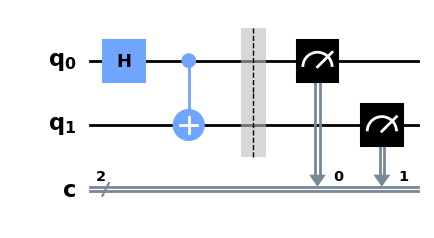

In [3]:
from qiskit import QuantumCircuit, transpile
from qiskit.providers.basic_provider import BasicSimulator
import numpy as np
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram

# 1. Create the Bell state (|ψ⟩ = (|00⟩ + |11⟩)/√2)
circuit = QuantumCircuit(2, 2)
circuit.h(0)
circuit.cx(0, 1)
circuit.barrier()

# 2. Define measurement bases (for a simple Bell test, we'll use the Z basis for both qubits)
# In a more complex Bell test, you would rotate the measurement bases.
circuit.measure([0, 1], [0, 1])

# 3. Simulate the circuit for 1024 shots
simulator = BasicSimulator()
compiled_circuit = transpile(circuit, simulator)
job = simulator.run(compiled_circuit, shots=100)
result = job.result()
counts = result.get_counts(circuit)
circuit.draw(output="mpl", style="clifford", fold=40)

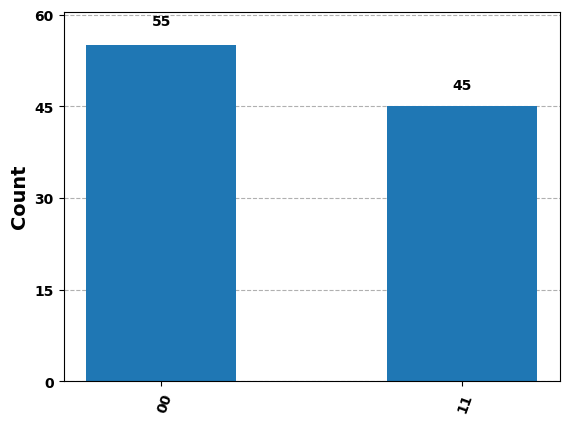

In [4]:
histogram_data = counts
hist_plt = plot_histogram(counts)
hist_plt

[0.03141593 0.03141593]


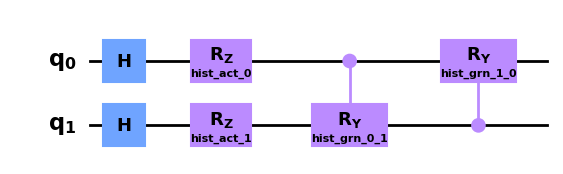

In [5]:
act_percentages = np.array([np.pi*0.01, np.pi*0.01])
print(act_percentages)
cirq = create_grn_ansatz(2, "hist")
cirq.draw(output="mpl", style="clifford", fold=40)

Interaction observable CT1 from histogram: SparsePauliOp(['ZZ'],
              coeffs=[-45.+0.j])
Static Parameters: {}
Variable Parameters (initialized to 0.0): {Parameter(hist_act_0): 0.031415926535897934, Parameter(hist_act_1): 0.031415926535897934, Parameter(hist_grn_0_1): 3.141592653589793, Parameter(hist_grn_1_0): 3.141592653589793}

Optimization Result:
  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -44.999999999993435
        x: [ 3.445e-07  4.608e-07  1.571e+00  1.231e+00]
      nit: 11
      jac: [ 1.421e-06  7.816e-06 -2.842e-06  1.563e-05]
     nfev: 65
     njev: 13
 hess_inv: <4x4 LbfgsInvHessProduct with dtype=float64>

Optimized Full Parameters:
  hist_act_0: 3.445383962241103e-07
  hist_act_1: 4.6075196570767403e-07
  hist_grn_0_1: 1.5707962689678845
  hist_grn_1_0: 1.2309598983423127


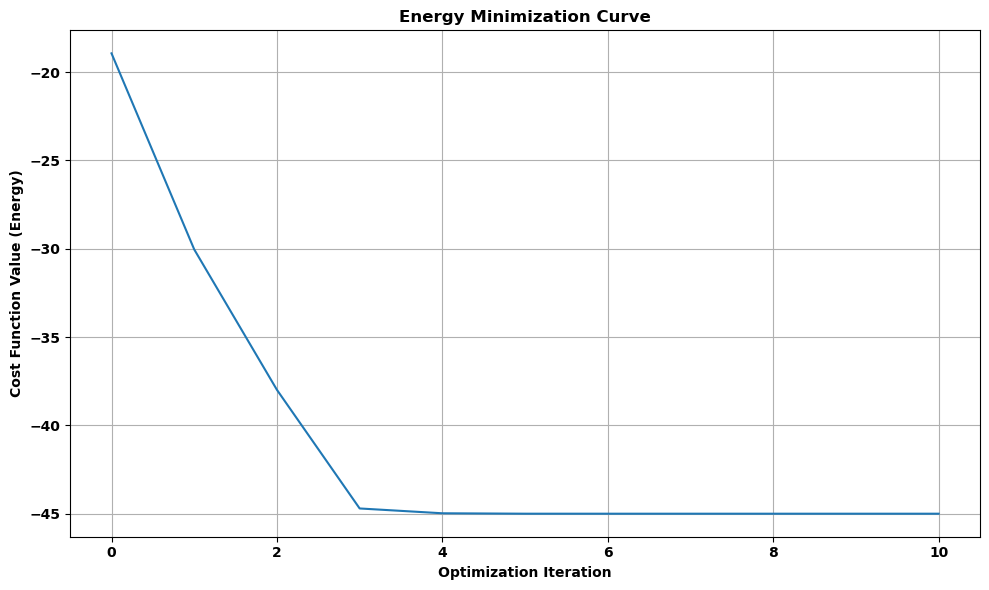

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize

num_qubits = cirq.num_qubits # Get number of qubits from the circuit
min_ones_for_observable = 1
# 1. Create interaction observable
interaction_observable = create_interaction_observable_from_histogram(
    histogram_data, num_qubits, min_ones_for_observable)
print("Interaction observable CT1 from histogram:", interaction_observable)

# 2. Create static and variable parameter dictionaries
# Ensure you are using create_parameter_dictionaries_cust here, not create_parameter_dictionaries
static_params, variable_params = create_parameter_dictionaries_cust(
    cirq, act_percentages)

print("Static Parameters:", static_params)
print("Variable Parameters (initialized to 0.0):", variable_params)

# 3. Initialize Qiskit Estimator
estimator = StatevectorEstimator()

# 4. Prepare initial guess for optimization
x0_interaction = np.array(list(variable_params.values()))
variable_param_objects = list(variable_params.keys())

# 5. Create initial full parameter dictionary (this is mainly for initial print and structure)
all_params = static_params.copy()
all_params.update(dict(zip(variable_param_objects, x0_interaction)))

cost_values = []
# Call minimize with args
result_interaction_bfgs = minimize(
    cost_func_wrapper,
    x0_interaction,
    args=(all_params, cirq, interaction_observable, estimator, variable_params), # Pass all the arguments as a tuple
    method="L-BFGS-B",
    callback=lambda xk: cost_values.append(cost_func_wrapper(xk, all_params, cirq, interaction_observable, estimator, variable_params))
)

print("\nOptimization Result:")
print(result_interaction_bfgs)

# 7. Update the full parameter dictionary with optimized variable parameters
optimized_variable_parameters = result_interaction_bfgs.x

# Construct the final optimized full parameter dictionary
optimized_full_params = static_params.copy()
for param_obj, value in zip(variable_param_objects, optimized_variable_parameters):
    optimized_full_params[param_obj] = value

print("\nOptimized Full Parameters:")
# Print optimized parameters by name for readability
for param, value in optimized_full_params.items():
    print(f"  {param.name}: {value}")

import matplotlib.pyplot as plt

# Plot the cost function values
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
plt.show()

The counts are: {'11': 785, '00': 239}


C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:197: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


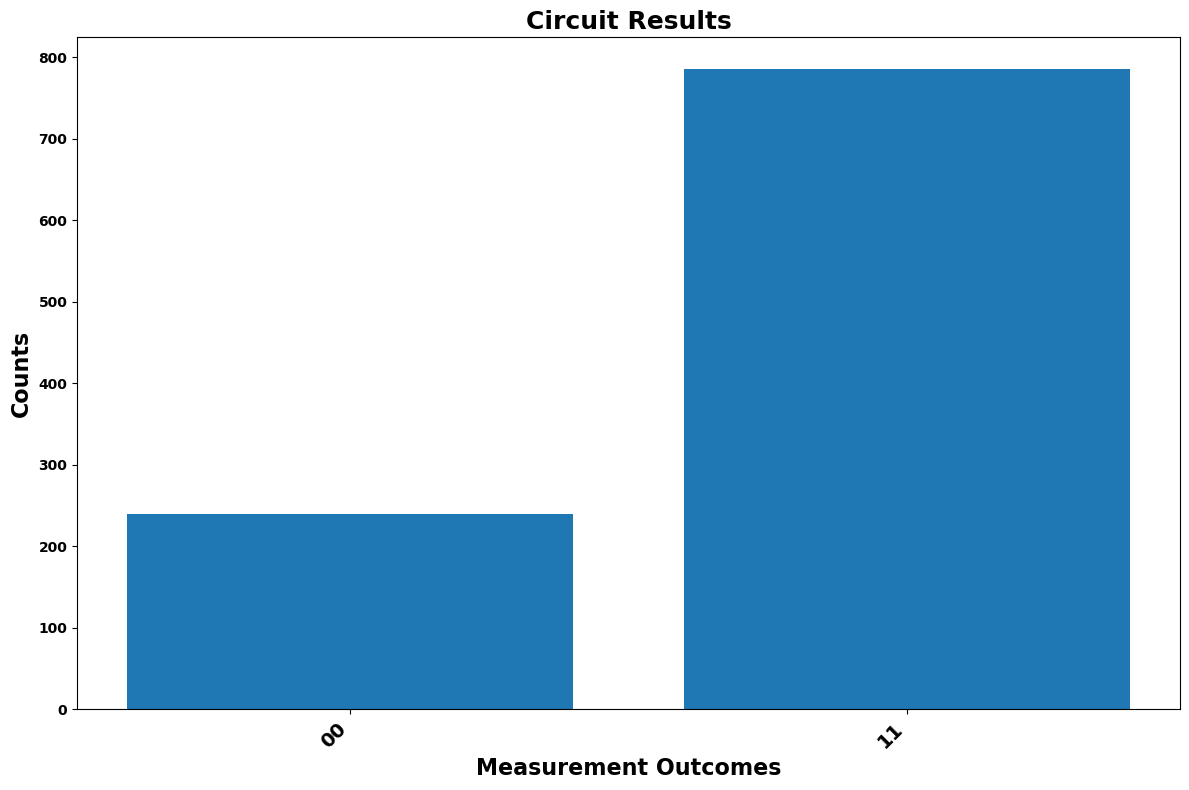

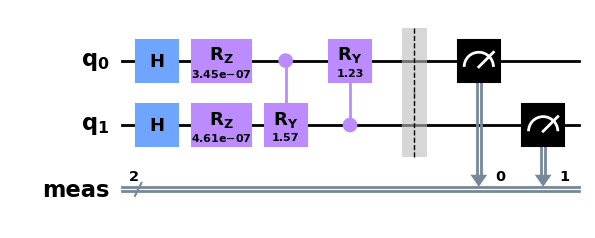

In [7]:
counts, bound_circuit = evaluate_and_plot_ansatz(cirq, optimized_full_params, shots=1024, title="Circuit Results")
bound_circuit.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

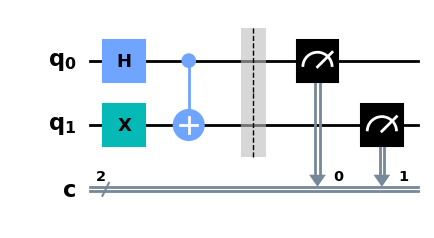

In [8]:
from qiskit import QuantumCircuit, transpile
from qiskit.providers.basic_provider import BasicSimulator
import numpy as np
import matplotlib.pyplot as plt

# 1. Create the Bell state (|ψ⟩ = (|00⟩ + |11⟩)/√2)
circuit = QuantumCircuit(2, 2)
circuit.x(1)
circuit.h(0)
circuit.cx(0, 1)
circuit.barrier()

# 2. Define measurement bases (for a simple Bell test, we'll use the Z basis for both qubits)
# In a more complex Bell test, you would rotate the measurement bases.
circuit.measure([0, 1], [0, 1])

# 3. Simulate the circuit for 1024 shots
simulator = BasicSimulator()
compiled_circuit = transpile(circuit, simulator)
job = simulator.run(compiled_circuit, shots=100)
result = job.result()
counts = result.get_counts(circuit)
circuit.draw(output="mpl", style="clifford", fold=40)


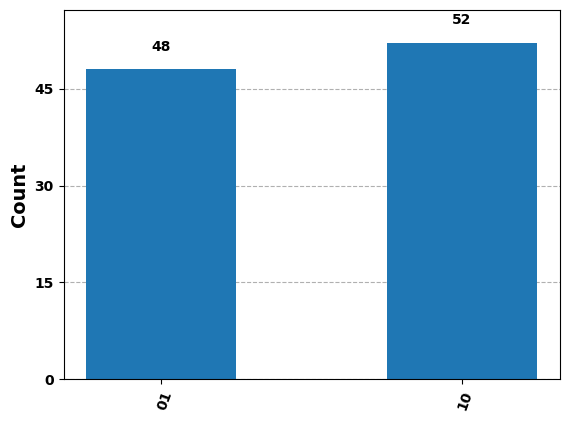

In [9]:
histogram_data = counts
hist_plt = plot_histogram(counts)
hist_plt

[0.31415927 0.31415927]


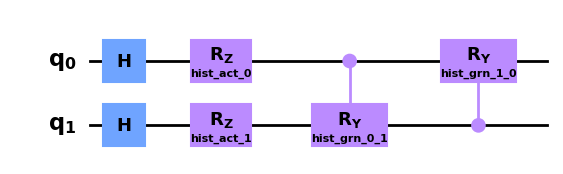

In [10]:
act_percentages = np.array([np.pi*0.1, np.pi*0.1])
print(act_percentages)
cirq = create_grn_ansatz(2, "hist")
cirq.draw(output="mpl", style="clifford", fold=40)

Interaction observable CT1 from histogram: SparsePauliOp(['IZ', 'ZI'],
              coeffs=[-48.+0.j, -52.+0.j])
Static Parameters: {}
Variable Parameters (initialized to 0.0): {Parameter(hist_act_0): 0.3141592653589793, Parameter(hist_act_1): 0.3141592653589793, Parameter(hist_grn_0_1): 3.141592653589793, Parameter(hist_grn_1_0): 3.141592653589793}

Optimization Result:
  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: -25.999999999998618
        x: [ 4.464e-01  1.455e-07  4.712e+00  6.283e+00]
      nit: 13
      jac: [ 0.000e+00 -2.487e-06 -7.461e-06  2.487e-06]
     nfev: 90
     njev: 18
 hess_inv: <4x4 LbfgsInvHessProduct with dtype=float64>

Optimized Full Parameters:
  hist_act_0: 0.44640998518425934
  hist_act_1: 1.454589318235582e-07
  hist_grn_0_1: 4.712388223901127
  hist_grn_1_0: 6.283184483042108


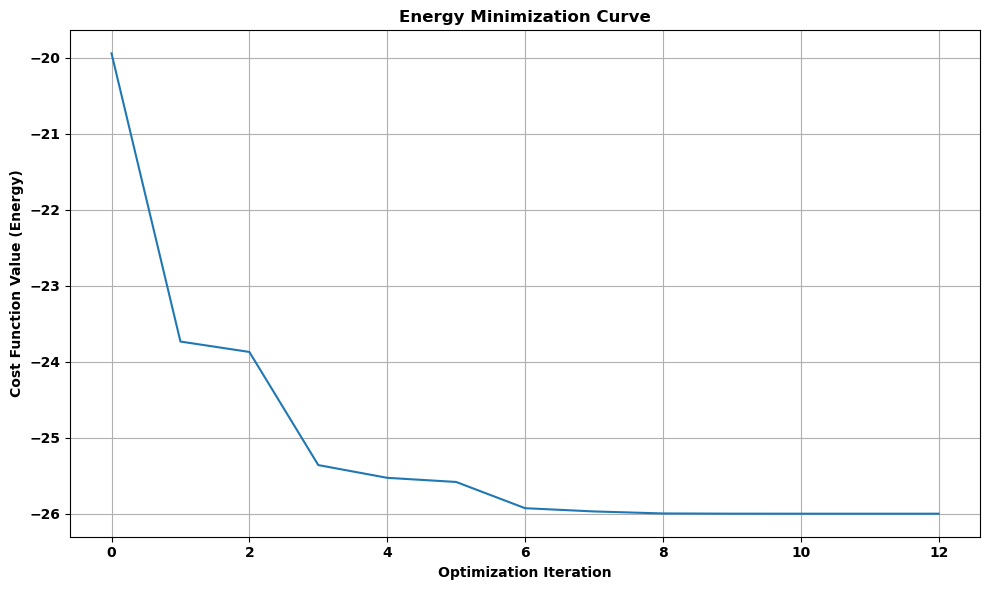

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize

num_qubits = cirq.num_qubits # Get number of qubits from the circuit
min_ones_for_observable = 1
# 1. Create interaction observable
interaction_observable = create_interaction_observable_from_histogram(
    histogram_data, num_qubits, min_ones_for_observable)
print("Interaction observable CT1 from histogram:", interaction_observable)

# 2. Create static and variable parameter dictionaries
# Ensure you are using create_parameter_dictionaries_cust here, not create_parameter_dictionaries
static_params, variable_params = create_parameter_dictionaries_cust(
    cirq, act_percentages)

print("Static Parameters:", static_params)
print("Variable Parameters (initialized to 0.0):", variable_params)

# 3. Initialize Qiskit Estimator
estimator = StatevectorEstimator()

# 4. Prepare initial guess for optimization
x0_interaction = np.array(list(variable_params.values()))
variable_param_objects = list(variable_params.keys())

# 5. Create initial full parameter dictionary (this is mainly for initial print and structure)
all_params = static_params.copy()
all_params.update(dict(zip(variable_param_objects, x0_interaction)))

cost_values = []
# Call minimize with args
result_interaction_bfgs = minimize(
    cost_func_wrapper,
    x0_interaction,
    args=(all_params, cirq, interaction_observable, estimator, variable_params), # Pass all the arguments as a tuple
    method="L-BFGS-B",
    callback=lambda xk: cost_values.append(cost_func_wrapper(xk, all_params, cirq, interaction_observable, estimator, variable_params))
)

print("\nOptimization Result:")
print(result_interaction_bfgs)

# 7. Update the full parameter dictionary with optimized variable parameters
optimized_variable_parameters = result_interaction_bfgs.x

# Construct the final optimized full parameter dictionary
optimized_full_params = static_params.copy()
for param_obj, value in zip(variable_param_objects, optimized_variable_parameters):
    optimized_full_params[param_obj] = value

print("\nOptimized Full Parameters:")
# Print optimized parameters by name for readability
for param, value in optimized_full_params.items():
    print(f"  {param.name}: {value}")

import matplotlib.pyplot as plt

# Plot the cost function values
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
plt.show()

The counts are: {'01': 492, '00': 255, '10': 277}


C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:197: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


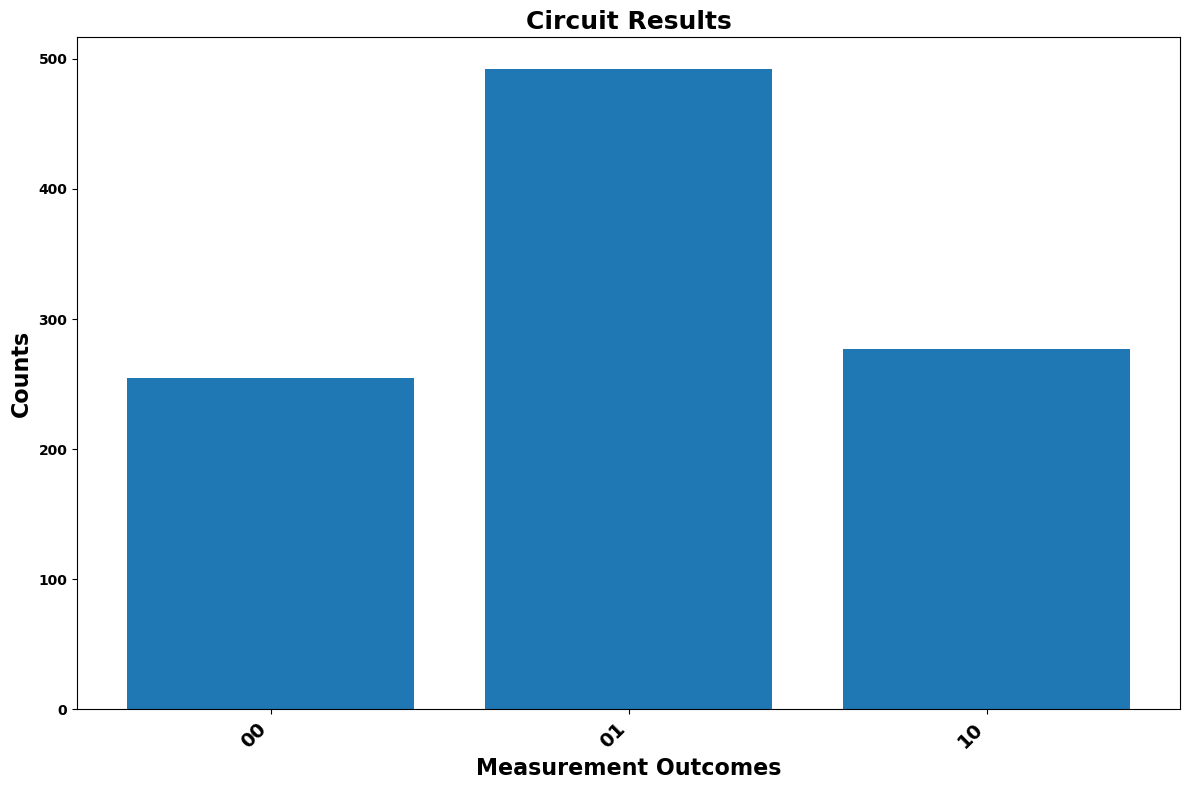

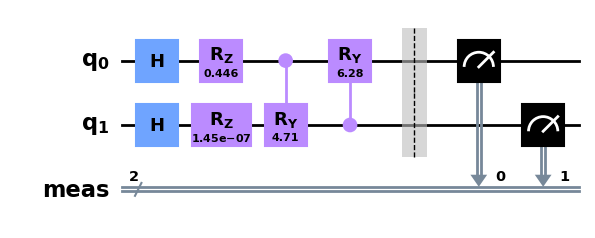

In [12]:
counts, bound_circuit = evaluate_and_plot_ansatz(cirq, optimized_full_params, shots=1024, title="Circuit Results")
bound_circuit.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

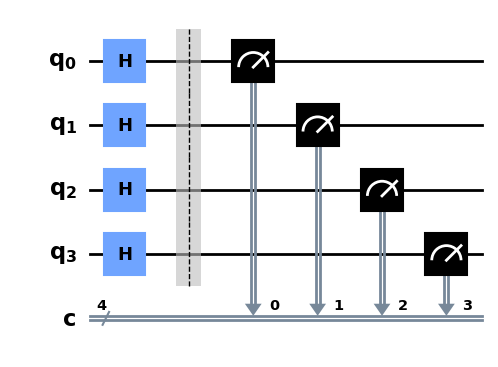

In [35]:
from qiskit import QuantumCircuit, transpile
from qiskit.providers.basic_provider import BasicSimulator
import numpy as np
import matplotlib.pyplot as plt

# 1. Create the 3-qubit GHZ-like state
# |ψ⟩ = (|000⟩ + |111⟩)/√2
circuit = QuantumCircuit(4, 4) # Initialize with 3 qubits and 3 classical bits

circuit.h(0)
circuit.h(1)
circuit.h(2)
circuit.h(3)
#circuit.x(1)
#circuit.x(2)
#circuit.cx(0, 1)
#circuit.cx(1, 2)
#circuit.cx(2, 3)

circuit.barrier()

# 2. Measure all three qubits
circuit.measure([0, 1, 2, 3], [0, 1, 2, 3])

# 3. Simulate the circuit for 1024 shots
simulator = BasicSimulator()
compiled_circuit = transpile(circuit, simulator)
job = simulator.run(compiled_circuit, shots=1024)
result = job.result()
counts = result.get_counts(circuit)
circuit.draw(output="mpl", style="clifford", fold=40)


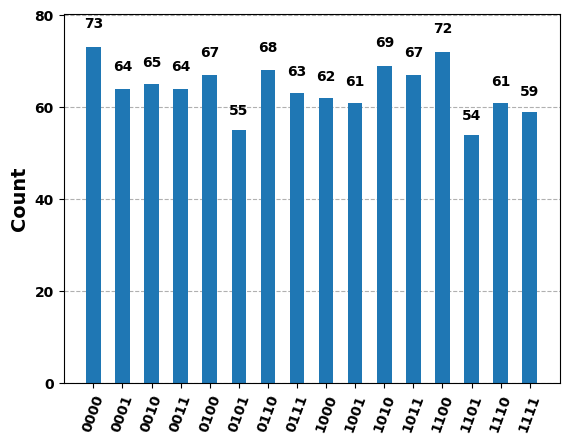

In [36]:
histogram_data = counts
hist_plt = plot_histogram(counts)
hist_plt

[0.31415927 0.31415927 0.31415927 0.31415927]


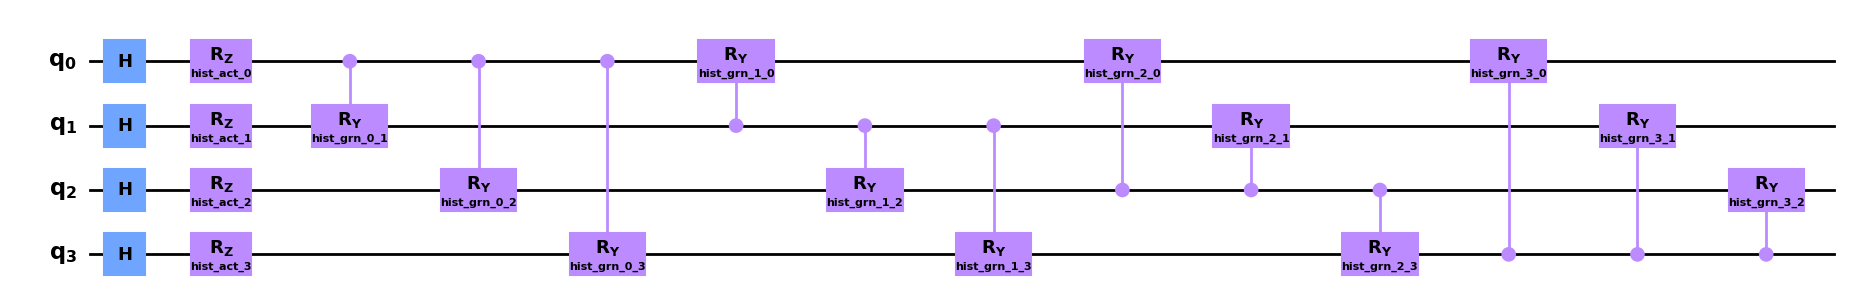

In [37]:
act_percentages = np.array([np.pi*0.1, np.pi*0.1, np.pi*0.1, np.pi*0.1])
print(act_percentages)
cirq = create_grn_ansatz(4, "hist")
cirq.draw(output="mpl", style="clifford", fold=40)

Interaction observable from histogram: SparsePauliOp(['ZIZZ', 'IZZZ', 'ZZIZ', 'ZZZI', 'ZZZZ'],
              coeffs=[-67.+0.j, -63.+0.j, -54.+0.j, -61.+0.j, -59.+0.j])
Static Parameters: {}
Variable Parameters (initialized to 0.0): {Parameter(hist_act_0): 0.3141592653589793, Parameter(hist_act_1): 0.3141592653589793, Parameter(hist_act_2): 0.3141592653589793, Parameter(hist_act_3): 0.3141592653589793, Parameter(hist_grn_0_1): 3.141592653589793, Parameter(hist_grn_0_2): 3.141592653589793, Parameter(hist_grn_0_3): 3.141592653589793, Parameter(hist_grn_1_0): 3.141592653589793, Parameter(hist_grn_1_2): 3.141592653589793, Parameter(hist_grn_1_3): 3.141592653589793, Parameter(hist_grn_2_0): 3.141592653589793, Parameter(hist_grn_2_1): 3.141592653589793, Parameter(hist_grn_2_3): 3.141592653589793, Parameter(hist_grn_3_0): 3.141592653589793, Parameter(hist_grn_3_1): 3.141592653589793, Parameter(hist_grn_3_2): 3.141592653589793}

Optimization Result:
  message: CONVERGENCE: RELATIVE REDUCTION OF

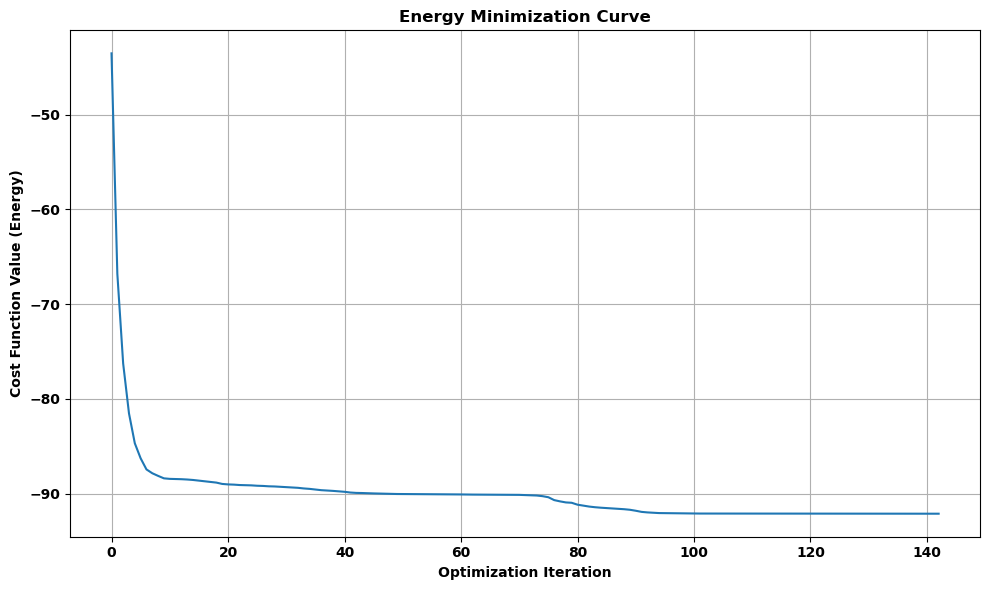

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize

num_qubits = cirq.num_qubits # Get number of qubits from the circuit
min_ones_for_observable = 3
# 1. Create interaction observable
interaction_observable = create_interaction_observable_from_histogram(
    histogram_data, num_qubits, min_ones_for_observable)
print("Interaction observable from histogram:", interaction_observable)

# 2. Create static and variable parameter dictionaries
# Ensure you are using create_parameter_dictionaries_cust here, not create_parameter_dictionaries
#static_params, variable_params = create_parameter_dictionaries(cirq, act_percentages)
static_params, variable_params = create_parameter_dictionaries_cust(cirq, act_percentages)


print("Static Parameters:", static_params)
print("Variable Parameters (initialized to 0.0):", variable_params)

# 3. Initialize Qiskit Estimator
estimator = StatevectorEstimator()

# 4. Prepare initial guess for optimization
x0_interaction = np.array(list(variable_params.values()))
variable_param_objects = list(variable_params.keys())

# 5. Create initial full parameter dictionary (this is mainly for initial print and structure)
all_params = static_params.copy()
all_params.update(dict(zip(variable_param_objects, x0_interaction)))

cost_values = []
# Call minimize with args
result_interaction_bfgs = minimize(
    cost_func_wrapper,
    x0_interaction,
    args=(all_params, cirq, interaction_observable, estimator, variable_params), # Pass all the arguments as a tuple
    method="L-BFGS-B",
    callback=lambda xk: cost_values.append(cost_func_wrapper(xk, all_params, cirq, interaction_observable, estimator, variable_params))
)

print("\nOptimization Result:")
print(result_interaction_bfgs)

# 7. Update the full parameter dictionary with optimized variable parameters
optimized_variable_parameters = result_interaction_bfgs.x

# Construct the final optimized full parameter dictionary
optimized_full_params = static_params.copy()
for param_obj, value in zip(variable_param_objects, optimized_variable_parameters):
    optimized_full_params[param_obj] = value

print("\nOptimized Full Parameters:")
# Print optimized parameters by name for readability
for param, value in optimized_full_params.items():
    print(f"  {param.name}: {value}")

import matplotlib.pyplot as plt

# Plot the cost function values
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
plt.show()

The counts are: {'1101': 951, '0000': 73}


C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:197: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


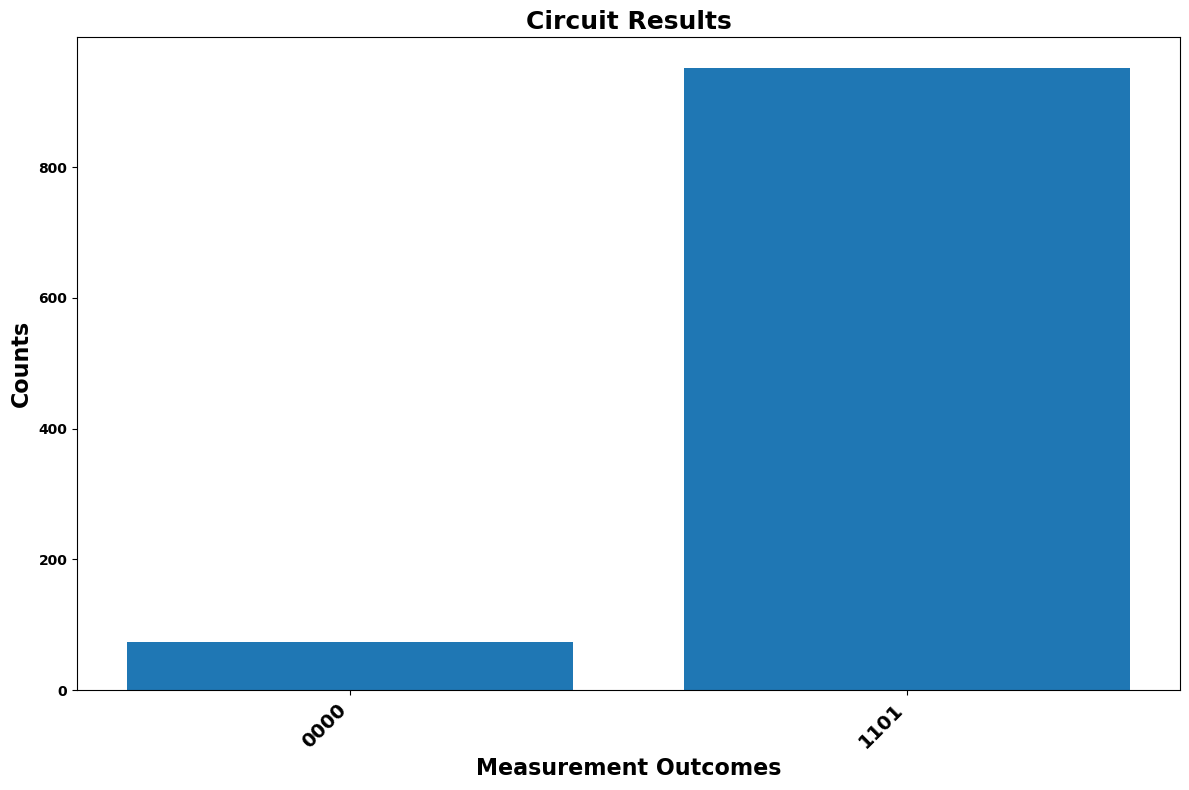

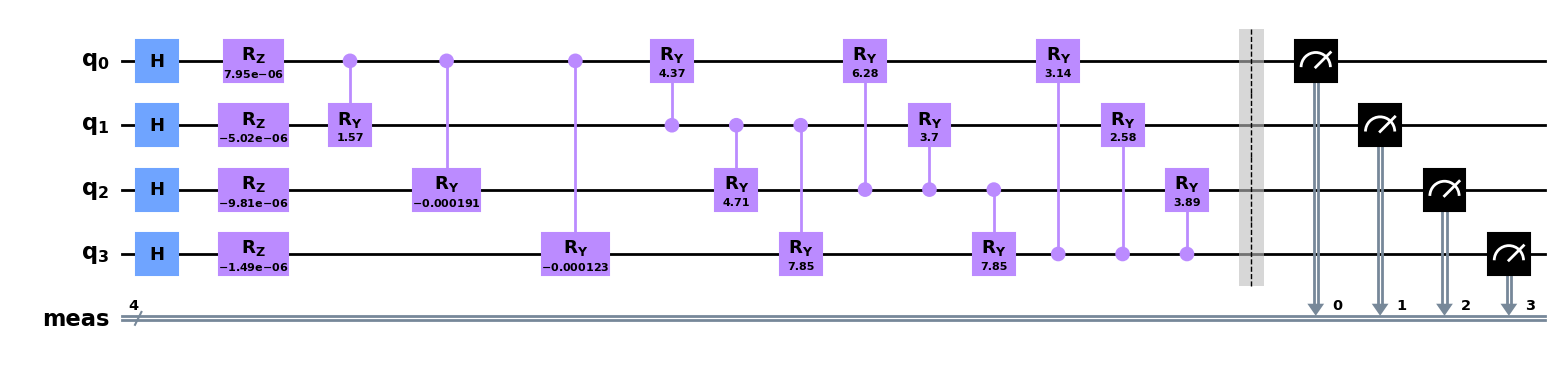

In [39]:
counts, bound_circuit = evaluate_and_plot_ansatz(cirq, optimized_full_params, shots=1024, title="Circuit Results")

bound_circuit.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot


Circuit Diagram (with Parameters):


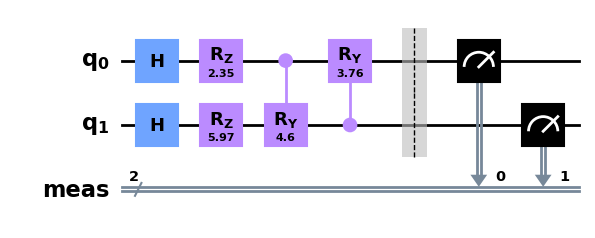

In [69]:
from qiskit import QuantumCircuit, transpile
from qiskit.providers.basic_provider import BasicSimulator
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit import Parameter # Import Parameter

# Set a random seed for reproducibility of angles
np.random.seed(42)

# Function to generate a random numerical value for parameters
def get_random_parameter_value():
    return np.random.uniform(0, 2 * np.pi)

# --- Define the number of qubits here ---
num_qubits = 2 # You can change this value to any desired number of qubits

# 1. Create the quantum circuit
# Initialize with num_qubits quantum bits and num_qubits classical bits
circuit = QuantumCircuit(num_qubits)
# num_features is now directly equivalent to num_qubits
num_features = circuit.num_qubits

# Dictionary to store all parameters and their initial static values
parameter_values = {}
all_qiskit_parameters = [] # To keep track of the Parameter objects created

# Define parameters for the initial Rz gates (activation parameters)
params_act = [Parameter(f"act_{i}") for i in range(num_features)]
for param in params_act:
    parameter_values[param] = get_random_parameter_value()
    all_qiskit_parameters.append(param)

# Define a placeholder for cell_type, as it was not defined in your snippet
cell_type = "ex_cell"

# --- Circuit Construction ---

# Apply Hadamard gates and Rz rotations to each qubit
for i in range(num_features):
    circuit.h(i)
    circuit.rz(params_act[i], i)  # Use RZ for activation with defined parameters

# Gene interaction CRy gates
# This loop structure creates CRy gates between all unique ordered pairs of qubits
for i in range(num_features):
    for j in range(num_features):
        if i != j:
            param_name = f'{cell_type}_grn_{i}_{j}'
            param = Parameter(param_name)
            circuit.cry(param, i, j) # Using CRy as per your snippet
            parameter_values[param] = get_random_parameter_value() # Assign a static random value
            all_qiskit_parameters.append(param)

# 2. Measure all qubits
# This is a more general way to measure all qubits into all classical bits
circuit.measure_all()

# 3. Simulate the circuit for 1024 shots
simulator = BasicSimulator()

# IMPORTANT: Assign the static random values to the parameters
# This creates a new circuit where all parameters are replaced by their numerical values.
bound_circuit = circuit.assign_parameters(parameter_values)

# Transpile and run the bound circuit
compiled_circuit = transpile(bound_circuit, simulator)
job = simulator.run(compiled_circuit, shots=1024)
result = job.result()
counts = result.get_counts(bound_circuit) # Get counts from the bound circuit
# Draw the circuit
print("\nCircuit Diagram (with Parameters):")
# Draw the original circuit with parameters for clarity, before binding
bound_circuit.draw(output="mpl", style="clifford", fold=40)

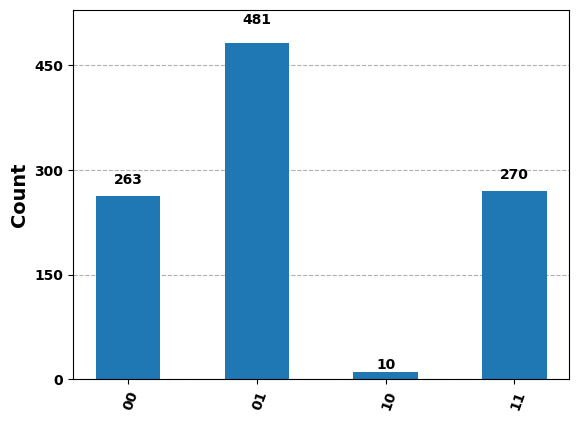

In [70]:
histogram_data = counts
hist_plt = plot_histogram(counts)
hist_plt

[3.14159265 3.14159265]


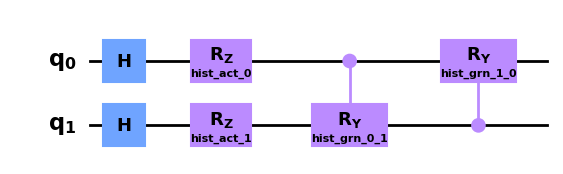

In [74]:
act_percentages = np.ones(num_qubits)*np.pi
print(act_percentages)
cirq = create_grn_ansatz(num_qubits, "hist")
cirq.draw(output="mpl", style="clifford", fold=40)

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize

num_qubits = cirq.num_qubits # Get number of qubits from the circuit
min_ones_for_observable = 3
# 1. Create interaction observable
interaction_observable = create_interaction_observable_from_histogram( joint_counts=histogram_data, 
                                                                      num_features=num_qubits, 
                                                                      min_ones=3,  rm_all_ones = True)
print("Interaction observable from histogram:", interaction_observable)

# 2. Create static and variable parameter dictionaries
# Ensure you are using create_parameter_dictionaries_cust here, not create_parameter_dictionaries
#static_params, variable_params = create_parameter_dictionaries(cirq, act_percentages)
static_params, variable_params = create_parameter_dictionaries_cust(cirq, act_percentages)


print("Static Parameters:", static_params)
print("Variable Parameters (initialized to 0.0):", variable_params)

# 3. Initialize Qiskit Estimator
estimator = StatevectorEstimator()

# 4. Prepare initial guess for optimization
x0_interaction = np.array(list(variable_params.values()))
variable_param_objects = list(variable_params.keys())

# 5. Create initial full parameter dictionary (this is mainly for initial print and structure)
all_params = static_params.copy()
all_params.update(dict(zip(variable_param_objects, x0_interaction)))

cost_values = []
# Call minimize with args
result_interaction_bfgs = minimize(
    cost_func_wrapper,
    x0_interaction,
    args=(all_params, cirq, interaction_observable, estimator, variable_params), # Pass all the arguments as a tuple
    method="L-BFGS-B",
    callback=lambda xk: cost_values.append(cost_func_wrapper(xk, all_params, cirq, interaction_observable, estimator, variable_params))
)

print("\nOptimization Result:")
print(result_interaction_bfgs)

# 7. Update the full parameter dictionary with optimized variable parameters
optimized_variable_parameters = result_interaction_bfgs.x

# Construct the final optimized full parameter dictionary
optimized_full_params = static_params.copy()
for param_obj, value in zip(variable_param_objects, optimized_variable_parameters):
    optimized_full_params[param_obj] = value

print("\nOptimized Full Parameters:")
# Print optimized parameters by name for readability
for param, value in optimized_full_params.items():
    print(f"  {param.name}: {value}")

import matplotlib.pyplot as plt

# Plot the cost function values
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
plt.show()

QiskitError: 'Could not determine the number of qubits from an empty list. Try passing num_qubits.'

The counts are: {'00': 243, '10': 781}


C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:197: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


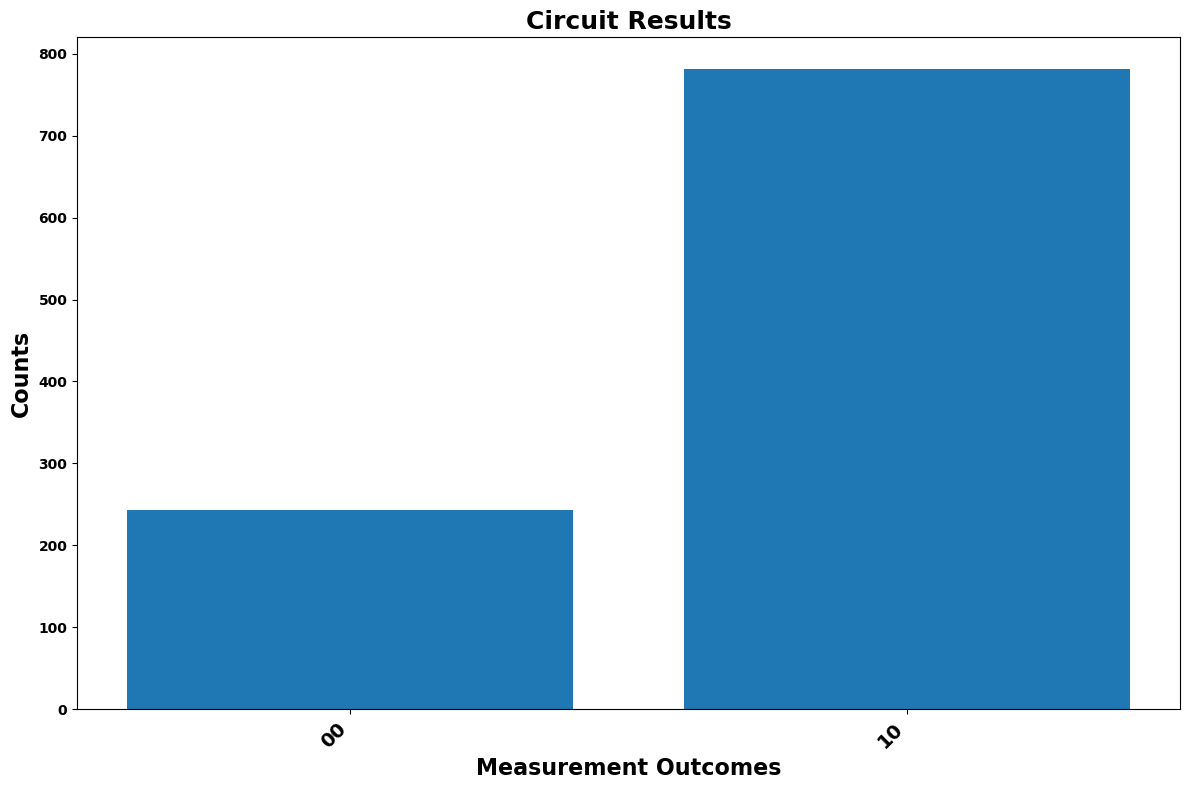

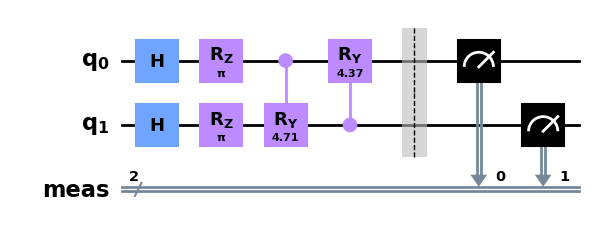

In [76]:
counts, bound_circuit = evaluate_and_plot_ansatz(cirq, optimized_full_params, shots=1024, title="Circuit Results")

bound_circuit.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot